In [44]:
#Exploratory Data Analysis-RACE Dataset
#Team: 23i-0620, 22i-1039

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

      

In [45]:
train = pd.read_csv('data/processed/train.csv')
dev   = pd.read_csv('data/processed/dev.csv')
test  = pd.read_csv('data/processed/test.csv')
print ('Train: ',train.shape)
print('Dev: ',dev.shape)
print('Test: ',test.shape)


Train:  (61506, 9)
Dev:  (13180, 9)
Test:  (13180, 9)


In [46]:
train.head(3)

,id,article,question,A,B,C,D,answer,combined_text
0,middle4234.txt,"Ann is my classmate. She comes from New York, ...",What is Ann's hope ?,To get fat.,To have more friends.,To speak Chinese well.,To live in New York.,C,ann is my classmate she comes from new york an...
1,high326.txt,The bicycling craze came in when we were just ...,How did the writer feel about tricycles?,They were very hard to ride.,Riding tricycles was an enjoyble arnusement.,They were not as fast as bicycles.,They were not proper for women to ride.,A,the bicycling craze came in when we were just ...
2,middle6947.txt,Qian Xuesen is one of the greatest scientists ...,What did Qian Xuesen do in Shanghai?,He got a mechanical engineering degree.,He became a great scientist.,He studied aeronautical engineering.,He wrote a suggestion for a winged space plane.,A,qian xuesen is one of the greatest scientists ...


In [52]:
train['article_words'] = train['article'].fillna('').str.split().str.len()
train['article_words'].describe().round(2)

count    61506.00
mean       274.77
std         97.92
min          2.00
25%        217.00
50%        279.00
75%        326.00
max       1162.00
Name: article_words, dtype: float64

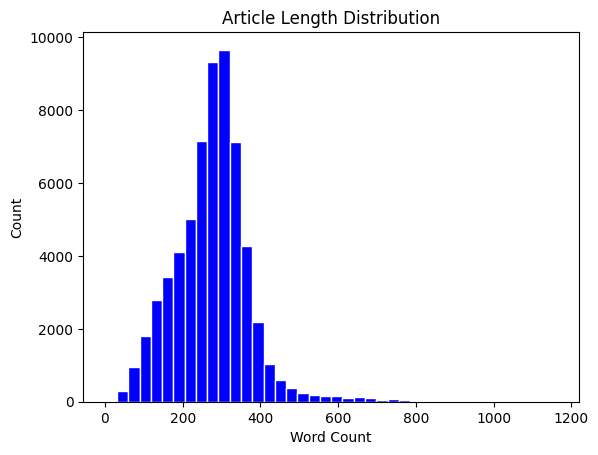

In [54]:
plt.hist(train['article_words'], bins=40, color='blue',edgecolor='white')
plt.title('Article Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Count')
plt.show()
        

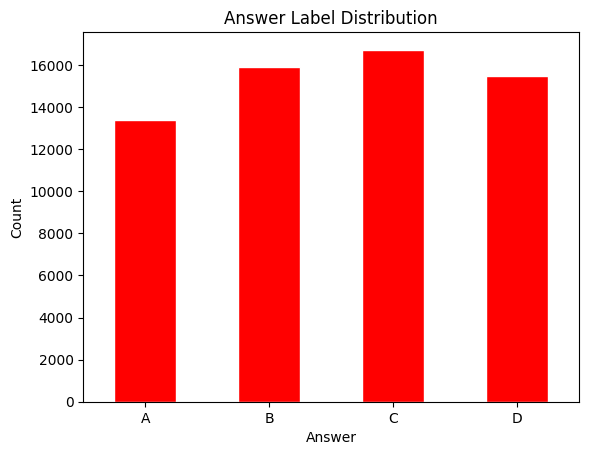

In [57]:
train['answer'].value_counts().sort_index().plot(kind='bar',color='red',edgecolor='white')
plt.title('Answer Label Distribution')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
                                                 

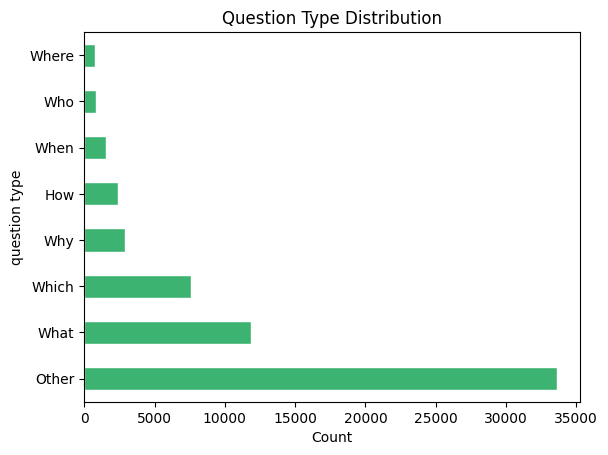

In [59]:
def get_type(q):
    q = str(q).lower()
    for w in ['what', 'which', 'who', 'when', 'where', 'why', 'how']:
        if q.startswith(w):
            return w.capitalize()
    return 'Other'

train['question type'] = train['question'].apply(get_type)
train['question type'].value_counts().plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Question Type Distribution')
plt.xlabel('Count')
plt.show()

In [60]:
total = len(train) + len(dev) + len(test)

print('Split Summary')
print(f'Train : {len(train)} rows  ({len(train)/total*100:.1f}%)')
print(f'Dev   : {len(dev)} rows  ({len(dev)/total*100:.1f}%)')
print(f'Test  : {len(test)} rows  ({len(test)/total*100:.1f}%)')

Split Summary
Train : 61506 rows  (70.0%)
Dev   : 13180 rows  (15.0%)
Test  : 13180 rows  (15.0%)


In [61]:
summary = {
    'Metric': [
        'Train rows', 'Dev rows', 'Test rows',
        'Avg article length', 'Most common question type',
        'Answer balance', 'Missing values'
    ],
    'Value': [
        len(train), len(dev), len(test),
        f"{train['article_words'].mean():.0f} words",
        train['question_type'].value_counts().index[0],
        'Balanced (stratified split)',
        'None'
    ]
}

pd.DataFrame(summary)

,Metric,Value
0,Train rows,61506
1,Dev rows,13180
2,Test rows,13180
3,Avg article length,275 words
4,Most common question type,Other
5,Answer balance,Balanced (stratified split)
6,Missing values,None
